In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_raw = pd.read_csv("../data/raw/train.csv")

In [13]:
corr = df_raw.corr(numeric_only=True)["Label"].drop("Label").abs().sort_values(ascending=False)
top15 = corr.head(15)
print(top15)

sttl                0.438861
ct_state_ttl        0.269203
dload               0.240863
dmean               0.206271
ct_srv_dst          0.194495
ct_srv_src          0.188683
ct_dst_ltm          0.184695
dttl                0.150072
ct_dst_src_ltm      0.145841
ct_src_ltm          0.140125
ct_src_dport_ltm    0.136044
sload               0.129210
rate                0.128725
swin                0.126032
ct_dst_sport_ltm    0.116014
Name: Label, dtype: float64


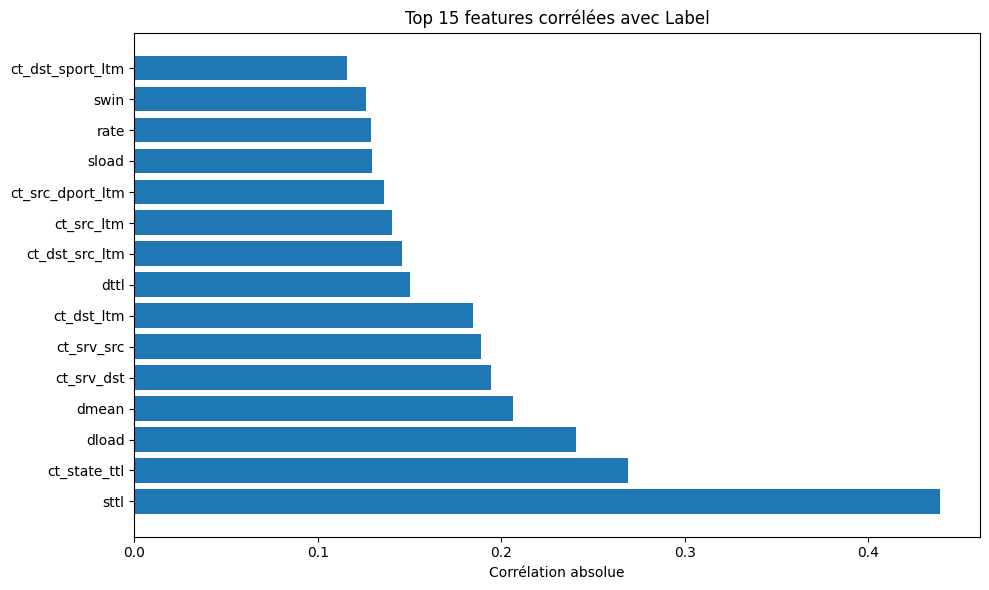

In [14]:
plt.figure(figsize=(10, 6))
plt.barh(top15.index, top15.values)
plt.title("Top 15 features corrélées avec Label")
plt.xlabel("Corrélation absolue")
plt.tight_layout()
plt.show()

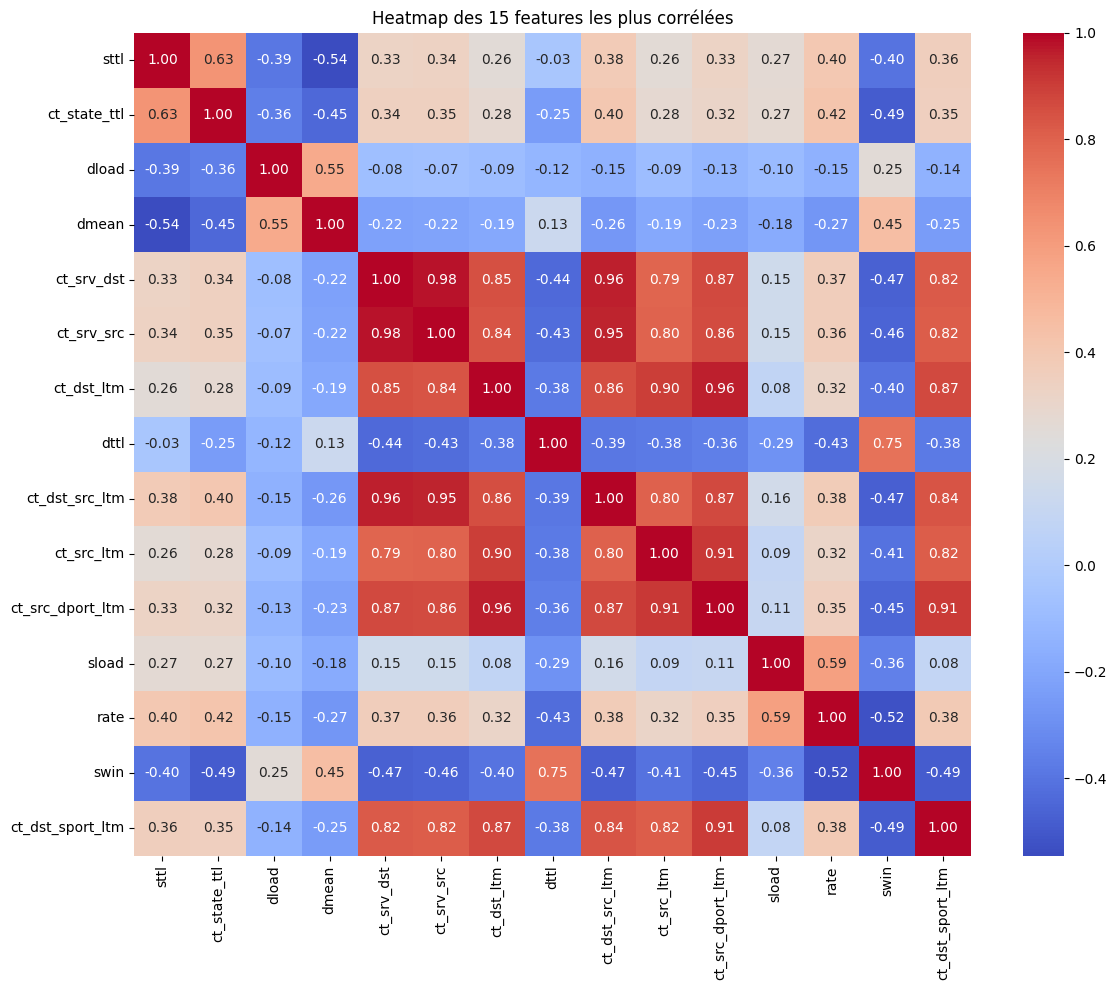

In [15]:
top15_features = top15.index.tolist()
corr_matrix = df_raw[top15_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap des 15 features les plus corrélées")
plt.tight_layout()
plt.show()

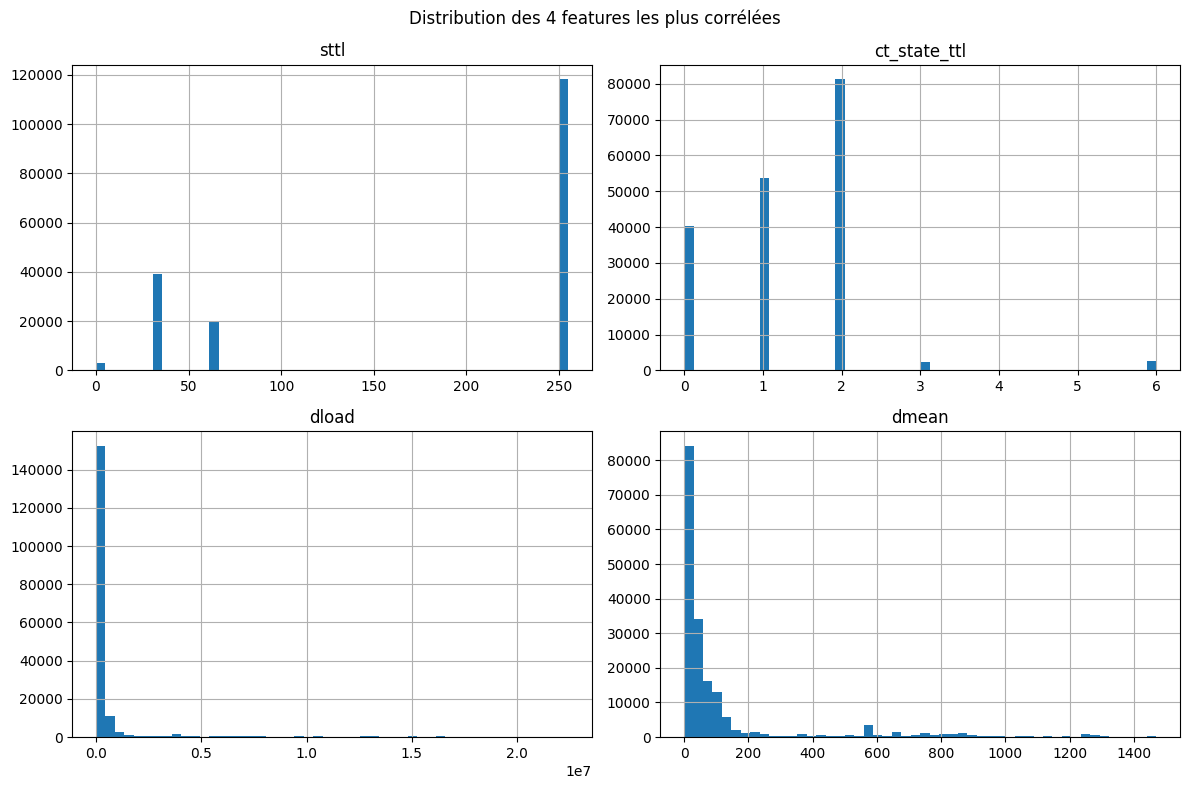

In [16]:
top4 = top15.index[:4].tolist()

df_raw[top4].hist(bins=50, figsize=(12, 8))
plt.suptitle("Distribution des 4 features les plus corrélées")
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

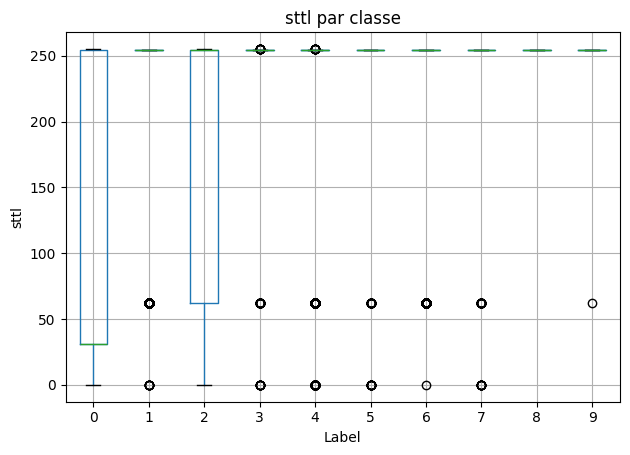

In [17]:
plt.figure(figsize=(12, 5))
df_raw.boxplot(column="sttl", by="Label")
plt.title("sttl par classe")
plt.suptitle("")
plt.xlabel("Label")
plt.ylabel("sttl")
plt.tight_layout()
plt.show()

**Conclusion:**

L'analyse exploratoire a révélé quatre informations clés pour la modélisation.

La distribution de la target confirme un déséquilibre sévère  Label 0 représente 51% du dataset tandis que Label 9 (Worms) n'en représente que 0.1%, ce qui justifie le SMOTE appliqué à l'étape précédente.

Le bar plot de corrélation montre que `sttl` est de loin la feature la plus corrélée avec la target (0.44), suivi de `ct_state_ttl` (0.26) et `dload` (0.24). Les corrélations restent modérées, ce qui indique que c'est la combinaison des features qui explique la target, pas une seule variable isolée.

La heatmap révèle une forte multicolinéarité entre les features `ct_*` notamment `ct_srv_dst` et `ct_srv_src` à 0.98. LightGBM gère ce problème nativement, mais ces features seront les premières candidates à supprimer si on fait de la sélection de features.

Les histogrammes montrent que `sttl` et `ct_state_ttl` ont des distributions discrètes avec peu de valeurs — ce sont des features quasi-catégorielles très exploitables par les arbres. `dload` et `dmean` sont fortement skewées et pourraient bénéficier d'une transformation log.

Le boxplot de `sttl` par classe confirme visuellement son pouvoir discriminant les labels 3 à 9 sont concentrés à 254, le label 1 à 0, et seuls les labels 0 et 2 ont une variance élevée.
